# Seaborn

[Seaborn Documentation](https://seaborn.pydata.org/examples/index.html)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns

In [2]:
tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.shape

(244, 7)

### Distribution Plots

<AxesSubplot:xlabel='total_bill', ylabel='Density'>

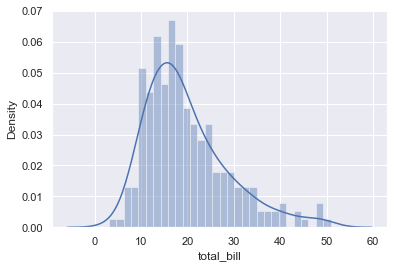

In [5]:
#Distribution plot (histogram) with KDE (kernal density estimation), use kde = False to remove
#Good for UNIVARIATE analysis

sns.set_theme() #Sets the theme for subsequent plots
sns.distplot(tips['total_bill'], bins=30)

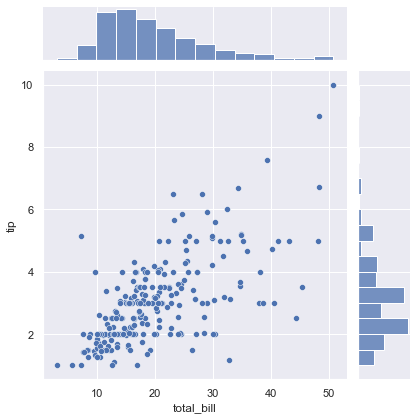

In [6]:
#Joint plot, combining two distribution plots
#Good for BIVARIATE analysis

sns.jointplot(x='total_bill',y='tip',data=tips)

In [7]:
# import numpy as np
# kind = np.array(['hex','reg','kde'])
# for item in kind:
#     sns.jointplot(x='total_bill',y='tip',data=tips, kind=item)

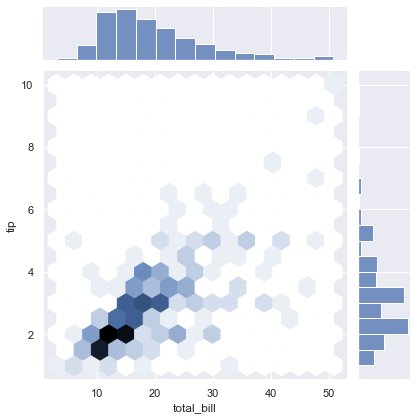

In [8]:
#Same plot as above, but with kind=HEX
sns.jointplot(x='total_bill',y='tip',data=tips, kind='hex')

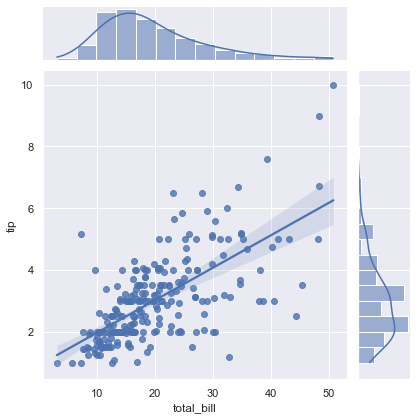

In [9]:
#Same plot as above, but with kind=reg, Seaborn draws a regression line instead
sns.jointplot(x='total_bill',y='tip',data=tips, kind='reg')

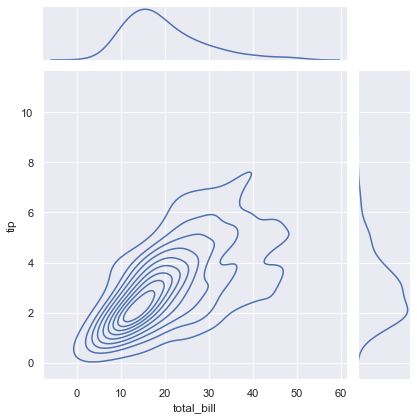

In [10]:
#Same plot as above, but with kind=kde, shows where dimension points match up the most
sns.jointplot(x='total_bill',y='tip',data=tips, kind='kde')

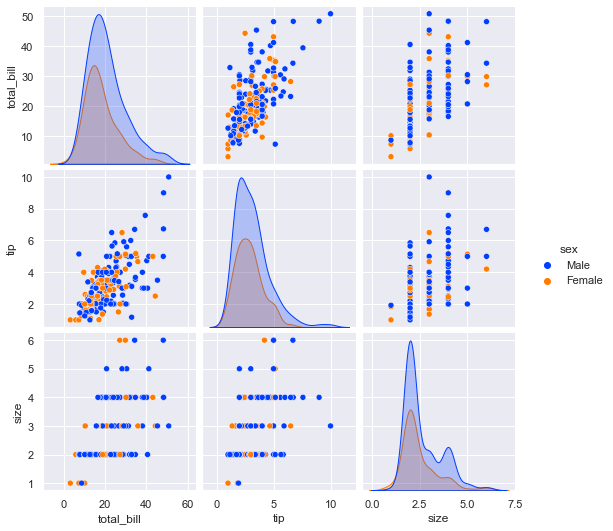

In [11]:
#Plot pairwise relationships across the entire dataframe for numerical columns
sns.pairplot(tips, hue='sex', palette='bright')

<AxesSubplot:xlabel='total_bill'>

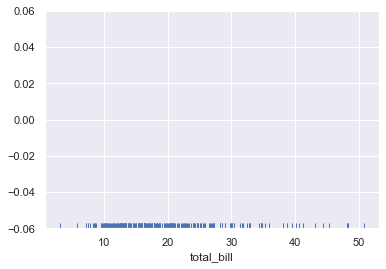

In [12]:
#Draws a dashed mark for every point from the variable we declare below
sns.rugplot(tips['total_bill'])

### Categorical Plots

In [13]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


##### Bar Plot

<AxesSubplot:xlabel='sex', ylabel='total_bill'>

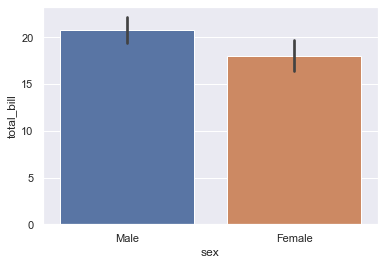

In [14]:
#Default is the average for each categorical column value
sns.barplot(x='sex', y='total_bill', data=tips)

In [15]:
import numpy as np

<AxesSubplot:xlabel='sex', ylabel='total_bill'>

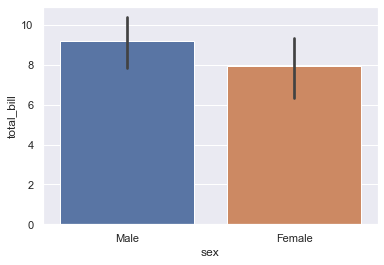

In [16]:
#Change the estimator object to affect the grouping behavior
sns.barplot(x='sex', y='total_bill', data=tips, estimator=np.std)

<AxesSubplot:xlabel='sex', ylabel='count'>

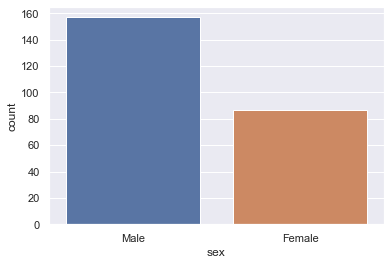

In [17]:
#Count the number of occurences for the variable, only set the X value in this case
sns.countplot(x='sex', data=tips) 

##### Box Plot

<AxesSubplot:xlabel='day', ylabel='total_bill'>

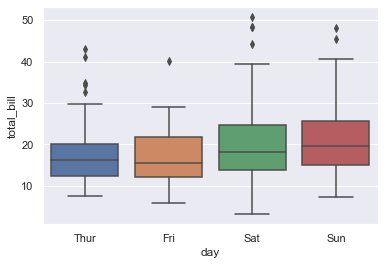

In [18]:
#Boxplot shows the distribution of quantitative data, five finger statistical summary
#X = categorical, Y= numerical
sns.boxplot(x='day', y='total_bill', data=tips)

<AxesSubplot:xlabel='day', ylabel='total_bill'>

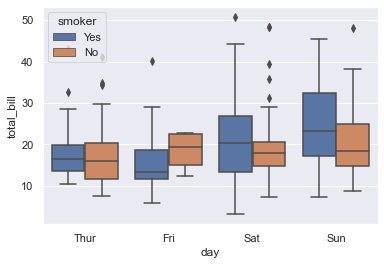

In [19]:
#Add the hue object to break out the visualization by another categorical variable, splits each box into smoker=Y/N
sns.boxplot(x='day', y='total_bill', data=tips, hue='smoker')

##### Violin Plot

<AxesSubplot:xlabel='day', ylabel='total_bill'>

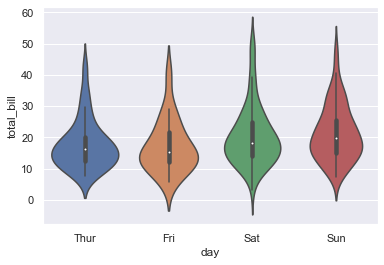

In [20]:
#Violin plot is similar to box plot, shows distribution of data across a category, as well as KDE of the underlying distribution
#X = categorical, Y= numerical
sns.violinplot(x='day', y='total_bill', data=tips)

<AxesSubplot:xlabel='day', ylabel='total_bill'>

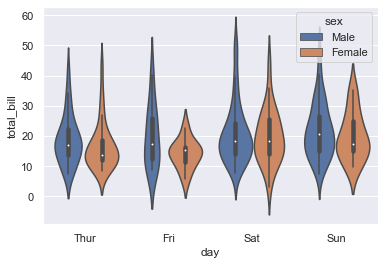

In [21]:
sns.violinplot(x='day', y='total_bill', data=tips, hue='sex')

<AxesSubplot:xlabel='day', ylabel='total_bill'>

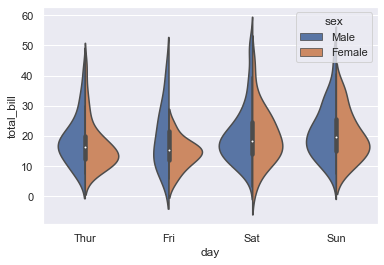

In [22]:
#Using split=True to see the distribution split down the middle based on our categories
sns.violinplot(x='day', y='total_bill', data=tips, hue='sex', split=True)

##### Strip Plot

<AxesSubplot:xlabel='day', ylabel='total_bill'>

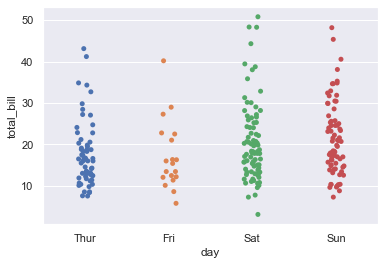

In [23]:
#Scatter plot where one variable is categorical
sns.stripplot(x='day', y='total_bill', data=tips)

<AxesSubplot:xlabel='day', ylabel='total_bill'>

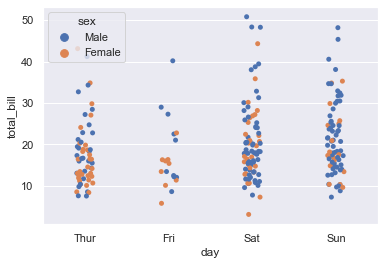

In [24]:
sns.stripplot(x='day', y='total_bill', data=tips, hue='sex')

<AxesSubplot:xlabel='day', ylabel='total_bill'>

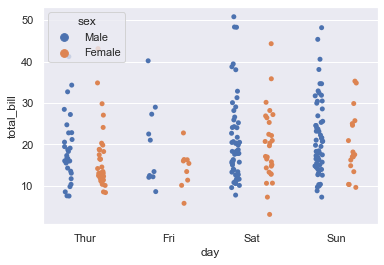

In [25]:
sns.stripplot(x='day', y='total_bill', data=tips, hue='sex', split=True)

##### Swarm Plot

<AxesSubplot:xlabel='day', ylabel='total_bill'>

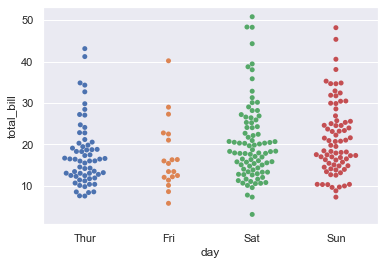

In [26]:
#Similar to a strip plot but the points are adjusted so that they don't overlap...Not great for large datasets
#Akin to a combination of a strip plot and a violin plot
sns.swarmplot(x='day', y='total_bill', data=tips)

##### Factor Plot

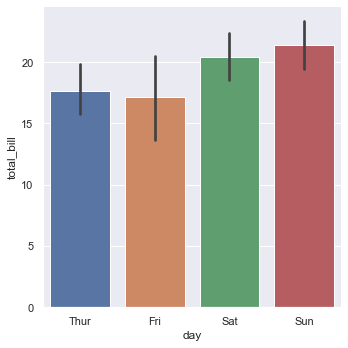

In [27]:
#General form of all these plots
sns.factorplot(x='day', y='total_bill', data=tips, kind='bar')

### Matrix Plots

##### Heatmaps

In [28]:
#In order for a heatmap to work properly, data should already be in a matrix form (variables on column headers and row headers)
tc = tips.corr()
tc

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<AxesSubplot:>

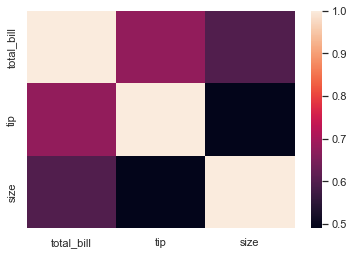

In [29]:
sns.heatmap(tc)

<AxesSubplot:>

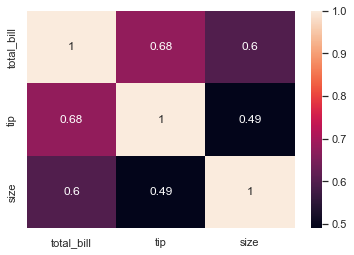

In [30]:
#Adding numbers for each matrix cell
sns.heatmap(tc, annot=True)

<AxesSubplot:>

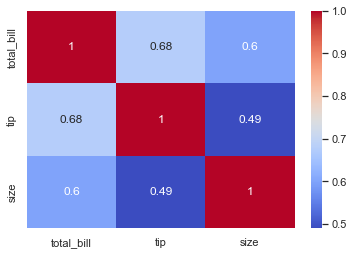

In [31]:
#Changing color scheme
sns.heatmap(tc, annot=True, cmap='coolwarm')

In [32]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [33]:
#Adding this as a pivot because we need a variable as the index
#NOT A CORRELATION, this essentially gets transferred as is into the heatmap function, and shows a heatmap for the COUNT
fp = flights.pivot_table(index='month', columns='year', values='passengers')
fp

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


<AxesSubplot:xlabel='year', ylabel='month'>

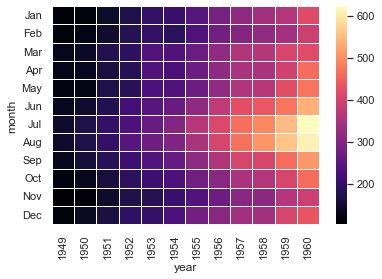

In [34]:
sns.heatmap(fp, cmap='magma', linecolor='white', linewidths=1)

##### Cluster Map

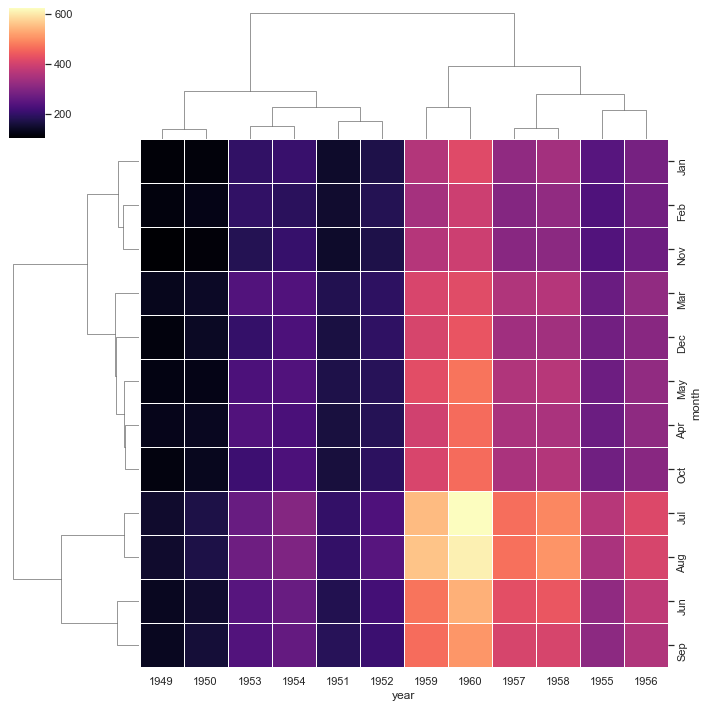

In [35]:
#Uses hierarchial clustering to produce a heatmap
#Meant to group months and years together (even if out of order visually below) based on how similar they are to one another
sns.clustermap(fp, cmap='magma', linecolor='white', linewidths=1)

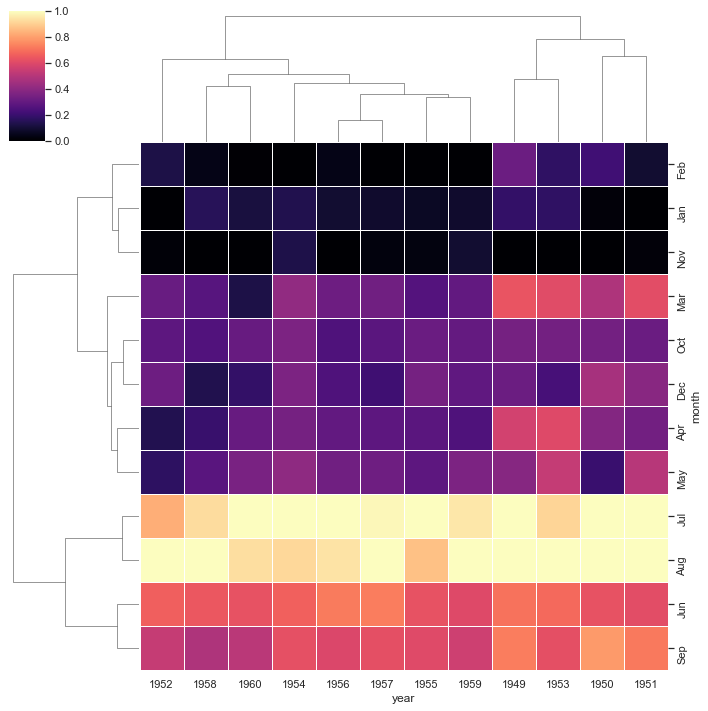

In [36]:
#Use standard_scale=1 to normalize the data and change the scale to 0 through 1
sns.clustermap(fp, cmap='magma', linecolor='white', linewidths=1, standard_scale=1)

### Grids

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline

In [38]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [39]:
iris.shape

(150, 5)

In [40]:
iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

##### Pair Grid

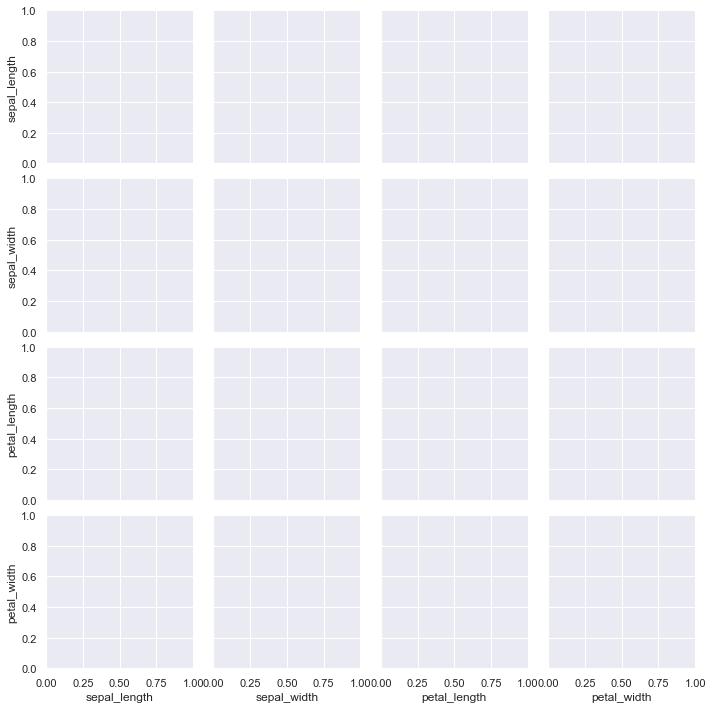

In [41]:
#Takes all of your variables, and creates an empty grid which we can add subplots to
#Gives us much more control over which plots are added to the grid, as opposed to pairplot
sns.PairGrid(iris)

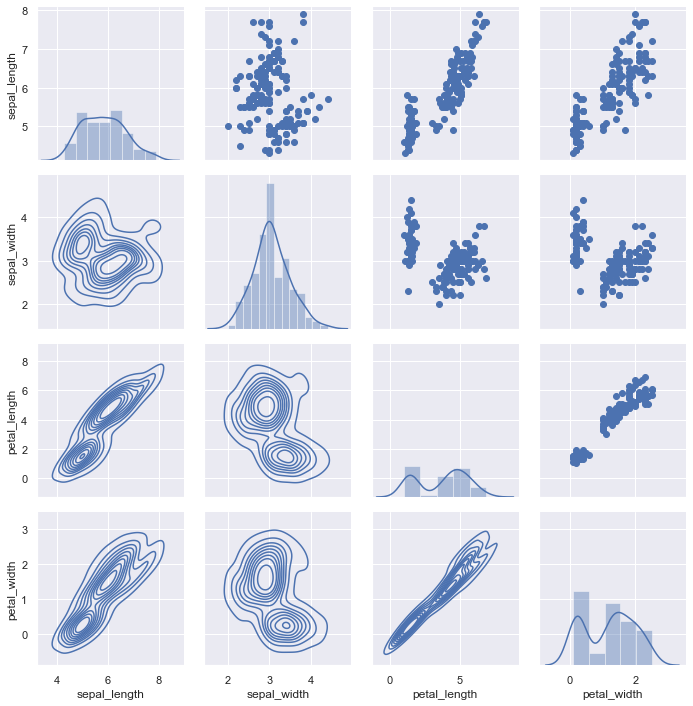

In [42]:
#Takes all of your variables, and creates an empty grid which we can add subplots to
g = sns.PairGrid(iris)
g.map_diag(sns.distplot)
g.map_upper(plt.scatter)
g.map_lower(sns.kdeplot)

##### Facet Grid

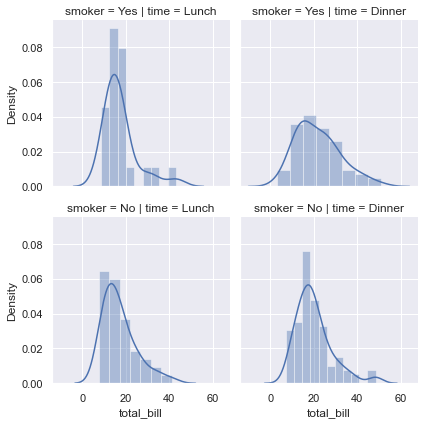

In [43]:
#SINGLE ARGUMENT VISUALIZATION (Distribution plot | total_bill)
#Mapping a plot type, and separating them into different visualizations based on columns and rows
g2 = sns.FacetGrid(data=tips, col='time', row='smoker')
g2.map(sns.distplot, 'total_bill')

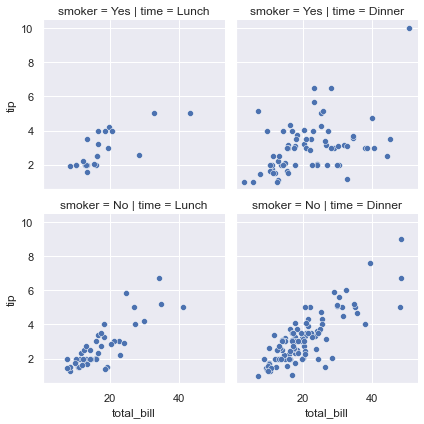

In [44]:
#TWO ARGUMENT VISUALIZATION (Scatter plot | total_bill & tip)
g3 = sns.FacetGrid(data=tips, col='time', row='smoker')
g3.map(sns.scatterplot, 'total_bill', 'tip')

### Regression Plots

##### Separating by category within same plot

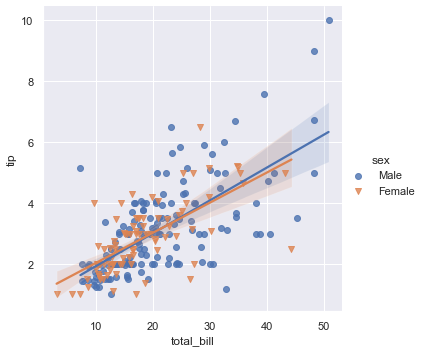

In [53]:
sns.lmplot(
    x='total_bill', 
    y='tip', 
    data=tips, 
    hue='sex', 
    markers=['o','v']) 

#, scatter_kws={'s': 100} for size of markers

##### Separating by category into two separate plots

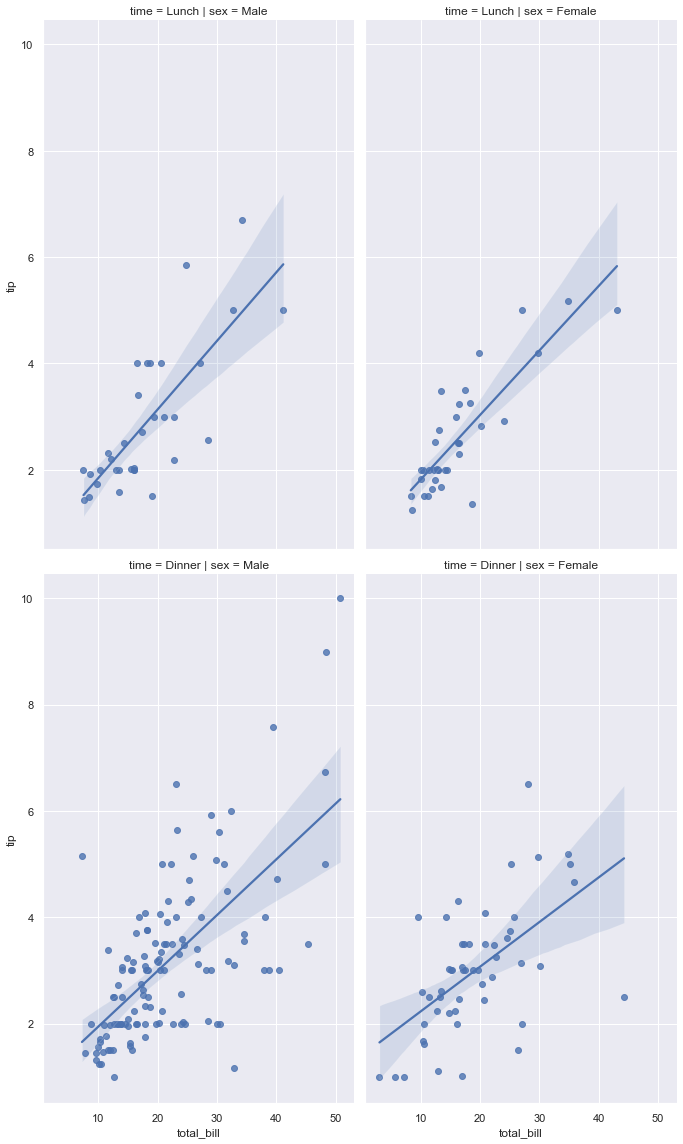

In [52]:
sns.lmplot(
    x='total_bill', 
    y='tip', 
    data=tips, 
    col='sex', 
    row='time', 
    aspect=0.6, 
    size=8) 

#Add hue back in for more variables

### Size & Style

<AxesSubplot:xlabel='sex', ylabel='count'>

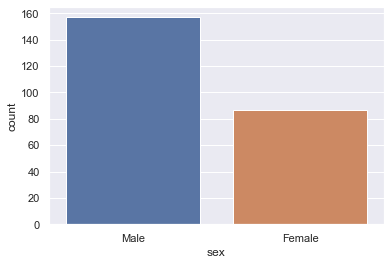

In [62]:
sns.set_style(style='darkgrid')
sns.countplot('sex', data=tips)

<AxesSubplot:xlabel='sex', ylabel='count'>

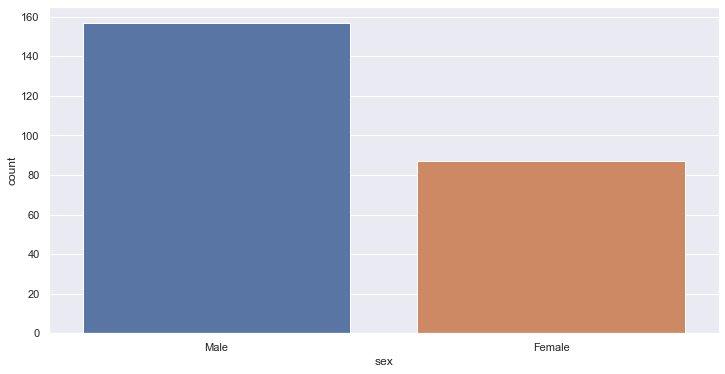

In [64]:
plt.figure(figsize=(12,6))
sns.countplot('sex', data=tips)